# BigMart Sales Intelligence & Prediction

## Executive Summary

This notebook builds a predictive model for BigMart item-outlet sales using machine learning, with a strong emphasis on **data-driven business insights**.

**Business Question:** Which product and outlet characteristics drive sales, and can we predict sales for new product-outlet combinations?


> **Note:** the specific feature rankings and model choice below reflect whichever algorithm the notebook's dynamic selection (Section 9, grouped-CV R²) picks on a given run. Re-check Sections 9 and 11 after re-running, since hyperparameter tuning or a change of best model can shift these.

**Key Findings:**
- **Outlet Type**, **MRP Segment**, and **Item MRP** dominate model predictions, in that order (see Feature Importance section)
- Tree-based models (Extra Trees / Random Forest) significantly outperform the baseline
- Outlet Type dominates predictions; product-level factors (MRP Segment, Item MRP) rank next
- Model performance on completely unseen products is evaluated via GroupKFold (see Cross-Validation section)

**Business Implications:**
- Outlet type selection is the single biggest lever on expected sales
- Pricing strategy (via MRP segment) is the next most important factor
- For unseen products, rely on baseline estimates or additional product-level features

**Recommendation:** Deploy model for familiar product portfolios; use baseline for new launches.

## Table of Contents

1. **Setup & Environment**
2. **Business Problem & Context**
3. **Data Understanding**
4. **Data Cleaning**
5. **Exploratory Data Analysis (EDA)**
   - Sales distribution & outliers
   - Product analysis
   - Outlet analysis
   - Key EDA Findings
6. **Feature Engineering & Selection**
7. **Data Preparation for Modeling**
8. **Model Comparison & Tuning**
9. **Cross-Validation**
10. **Error Analysis**
11. **Feature Importance & Explainability**
12. **Business Insights & Recommendations**
13. **Model Deployment**
14. **Conclusion**

## 1. Setup & Environment

In [1]:
# Environment & Reproducibility
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import os

# sklearn
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sklearn

# XGBoost & LightGBM
import xgboost as xgb
from lightgbm import LGBMRegressor

# SHAP for explainability
import shap

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"\nRandom Seed: {SEED}")

Pandas: 3.0.6
NumPy: 2.4.6
Scikit-learn: 1.9.1
XGBoost: 3.2.0

Random Seed: 42


## 2. Business Problem & Context

### The Challenge
BigMart operates 10 retail outlets selling thousands of products. Sales vary significantly across outlets and products. The business needs to:
- **Forecast** expected sales for product-outlet combinations
- **Identify** which factors drive sales performance
- **Optimize** inventory, pricing, and outlet strategy

### The Data
- **Training dataset:** 8,523 product-outlet sales records
- **Outlets:** 10 retail stores across 3 metropolitan tiers
- **Products:** 1,559 unique items across 16 categories
- **Target:** Item_Outlet_Sales (continuous, in INR)

### Success Criteria
- **Accuracy:** Achieve R² > 50% with MAE < ₹1,000
- **Interpretability:** Understand which factors matter most
- **Generalization:** Model should work on unseen product-outlet combinations (not just memorize known products)

## 3. Data Understanding

In [2]:
# Load data
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("TRAIN DATA")
print(f"Shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nData Types:")
print(train_df.dtypes)
print(f"\nFirst few rows:")
display(train_df.head())

TRAIN DATA
Shape: (8523, 12)
Columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']

Data Types:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

First few rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.02,Dairy,249.81,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.14
1,DRC01,5.92,Regular,0.02,Soft Drinks,48.27,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42
2,FDN15,17.50,Low Fat,0.02,Meat,141.62,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27
3,FDX07,19.20,Regular,0.00,Fruits and Vegetables,182.09,OUT010,1998,NaN,Tier 3,Grocery Store,732.38
4,NCD19,8.93,Low Fat,0.00,Household,53.86,OUT013,1987,High,Tier 3,Supermarket Type1,994.71


In [3]:
# Combine train and test for unified preprocessing
# (Using a marker column to separate them later)
train_df['_split'] = 'train'
test_df['_split'] = 'test'
test_df['Item_Outlet_Sales'] = np.nan  # No target in test set

df = pd.concat([train_df, test_df], ignore_index=True)

print(f"\nCombined shape: {df.shape}")
print(f"Train records: {(df['_split'] == 'train').sum()}")
print(f"Test records: {(df['_split'] == 'test').sum()}")


Combined shape: (14204, 13)
Train records: 8523
Test records: 5681


In [4]:
# Detailed data inventory
print("=" * 70)
print("DATA INVENTORY")
print("=" * 70)

for col in df.columns:
    print(f"\n{col}:")
    print(f"  Type: {df[col].dtype}")
    print(f"  Non-null: {df[col].notna().sum()} ({100*df[col].notna().sum()/len(df):.1f}%)")
    print(f"  Null: {df[col].isna().sum()}")
    print(f"  Unique values: {df[col].nunique()}")
    
    # Fixed condition - handles both 'object' and 'str' / 'string' dtypes
    if df[col].dtype == 'object' or str(df[col].dtype) in ['str', 'string']:
        print(f"  Values: {df[col].unique()[:5].tolist()}")
    else:
        print(f"  Range: [{df[col].min():.2f}, {df[col].max():.2f}]")

DATA INVENTORY

Item_Identifier:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 1559
  Values: ['FDA15', 'DRC01', 'FDN15', 'FDX07', 'NCD19']

Item_Weight:
  Type: float64
  Non-null: 11765 (82.8%)
  Null: 2439
  Unique values: 415
  Range: [4.55, 21.35]

Item_Fat_Content:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 5
  Values: ['Low Fat', 'Regular', 'low fat', 'LF', 'reg']

Item_Visibility:
  Type: float64
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 13006
  Range: [0.00, 0.33]

Item_Type:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 16
  Values: ['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables', 'Household']

Item_MRP:
  Type: float64
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 8052
  Range: [31.29, 266.89]

Outlet_Identifier:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 10
  Values: ['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027']

Outlet_Establishment_Year:
  Type: int64
  

In [5]:
# Duplicate check
duplicates = df.duplicated(subset=['Item_Identifier', 'Outlet_Identifier'], keep=False).sum()
print(f"Duplicate product-outlet combinations: {duplicates}")

# Product-level analysis
print(f"\nUnique products: {df['Item_Identifier'].nunique()}")
print(f"Unique outlets: {df['Outlet_Identifier'].nunique()}")
print(f"Expected max combinations: {df['Item_Identifier'].nunique() * df['Outlet_Identifier'].nunique()}")
print(f"Actual combinations: {len(df[df['_split']=='train'])}")

Duplicate product-outlet combinations: 0

Unique products: 1559
Unique outlets: 10
Expected max combinations: 15590
Actual combinations: 8523


In [6]:
# Descriptive statistics (training data only)
train_only = df[df['_split'] == 'train']

print("\nDESCRIPTIVE STATISTICS (Training Data)")
print(train_only[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']].describe())


DESCRIPTIVE STATISTICS (Training Data)
       Item_Weight  Item_Visibility  Item_MRP  Item_Outlet_Sales
count      7060.00          8523.00   8523.00            8523.00
mean         12.86             0.07    140.99            2181.29
std           4.64             0.05     62.28            1706.50
min           4.55             0.00     31.29              33.29
25%           8.77             0.03     93.83             834.25
50%          12.60             0.05    143.01            1794.33
75%          16.85             0.09    185.64            3101.30
max          21.35             0.33    266.89           13086.96


## 4. Data Cleaning

### Strategy
1. Standardize Item_Fat_Content values
2. Handle missing Item_Weight (impute with product-level average, then median)
3. Analyze Item_Visibility == 0 (back-stocked items)
4. Handle missing Outlet_Size (impute with mode by outlet)
5. Create Outlet_Age from Outlet_Establishment_Year

In [7]:
print(f"Missing values BEFORE cleaning:")
print(df.isnull().sum())

# Standardize Item_Fat_Content
print(f"\nItem_Fat_Content unique values: {df['Item_Fat_Content'].unique()}")
fat_mapping = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'Low Fat': 'Low Fat',
               'reg': 'Regular', 'Regular': 'Regular'}
df['Item_Fat_Content'] = df['Item_Fat_Content'].map(lambda x: fat_mapping.get(x, x))
print(f"After standardization: {df['Item_Fat_Content'].unique()}")

# Known BigMart data-quality quirk: non-consumable items (Household,
# Health and Hygiene, Others) carry a meaningless Low Fat / Regular tag
# because Item_Fat_Content doesn't apply to non-food products.
# Relabel these as 'Non-Edible' so the model isn't trained on a
# nonsensical fat-content signal for products that have none.
non_consumable_types = ['Household', 'Health and Hygiene', 'Others']
non_consumable_mask = df['Item_Type'].isin(non_consumable_types)
print(f"\nNon-consumable rows relabeled to 'Non-Edible': {non_consumable_mask.sum()}")
df.loc[non_consumable_mask, 'Item_Fat_Content'] = 'Non-Edible'
print(f"Item_Fat_Content values after fix: {df['Item_Fat_Content'].unique()}")

Missing values BEFORE cleaning:
Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
_split                          0
dtype: int64

Item_Fat_Content unique values: <ArrowStringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str
After standardization: <ArrowStringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str

Non-consumable rows relabeled to 'Non-Edible': 2686
Item_Fat_Content values after fix: <ArrowStringArray>
['Low Fat', 'Regular', 'Non-Edible']
Length: 3, dtype: str


In [8]:
# Handle Item_Weight: first with product average (train only), then median
print(f"\nItem_Weight missing: {df['Item_Weight'].isna().sum()}")

# Fit imputation stats on train split only to avoid leakage from test.csv
train_mask = df['_split'] == 'train'
product_weights = df.loc[train_mask].groupby('Item_Identifier')['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Identifier'].map(product_weights))

remaining_missing = df['Item_Weight'].isna().sum()
print(f"After product-level imputation (train-fit): {remaining_missing}")

if remaining_missing > 0:
    median_weight = df.loc[train_mask, 'Item_Weight'].median()
    df['Item_Weight'] = df['Item_Weight'].fillna(median_weight)
    print(f"Filled {remaining_missing} with train median: {median_weight:.2f}")

print(f"Final check: {df['Item_Weight'].isna().sum()} missing")



Item_Weight missing: 2439
After product-level imputation (train-fit): 5
Filled 5 with train median: 12.65
Final check: 0 missing


In [9]:
# Analyze Item_Visibility
vis_zero = (df['Item_Visibility'] == 0).sum()
print(f"\nItem_Visibility == 0: {vis_zero} records ({100*vis_zero/len(df):.1f}%)")
print("Interpretation: These are back-stocked items with no shelf visibility.")
print("Decision: Keep as-is (meaningful signal).")

# Check for missing visibility
print(f"\nItem_Visibility missing: {df['Item_Visibility'].isna().sum()}")


Item_Visibility == 0: 879 records (6.2%)
Interpretation: These are back-stocked items with no shelf visibility.
Decision: Keep as-is (meaningful signal).

Item_Visibility missing: 0


In [10]:
# Handle Outlet_Size
print(f"\nOutlet_Size missing: {df['Outlet_Size'].isna().sum()}")
print(f"Outlet_Size values: {df['Outlet_Size'].unique()}")

# Impute mode per outlet, fit on train split only to avoid leakage from test.csv
train_mask = df['_split'] == 'train'
outlet_size_mode_map = (
    df.loc[train_mask]
      .groupby('Outlet_Identifier')['Outlet_Size']
      .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Medium')
)
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Identifier'].map(outlet_size_mode_map))

print(f"After imputation (train-fit): {df['Outlet_Size'].isna().sum()} missing")



Outlet_Size missing: 4016
Outlet_Size values: <ArrowStringArray>
['Medium', nan, 'High', 'Small']
Length: 4, dtype: str
After imputation (train-fit): 0 missing


In [11]:
# Create Outlet_Age from Outlet_Establishment_Year
reference_year = 2013  # Latest year in training data
df['Outlet_Age'] = reference_year - df['Outlet_Establishment_Year']

print(f"\nOutlet_Age created (reference year: {reference_year})")
print(f"Range: {df['Outlet_Age'].min()} to {df['Outlet_Age'].max()} years")

print(f"\n\nMissing values AFTER cleaning:")
print(df.isnull().sum())


Outlet_Age created (reference year: 2013)
Range: 4 to 28 years


Missing values AFTER cleaning:
Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
_split                          0
Outlet_Age                      0
dtype: int64


## 5. Exploratory Data Analysis (EDA)

### Objective
Understand sales patterns, identify key drivers, and inform feature engineering.
We answer business questions, not just make plots.

### 5.1 Sales Distribution & Outliers

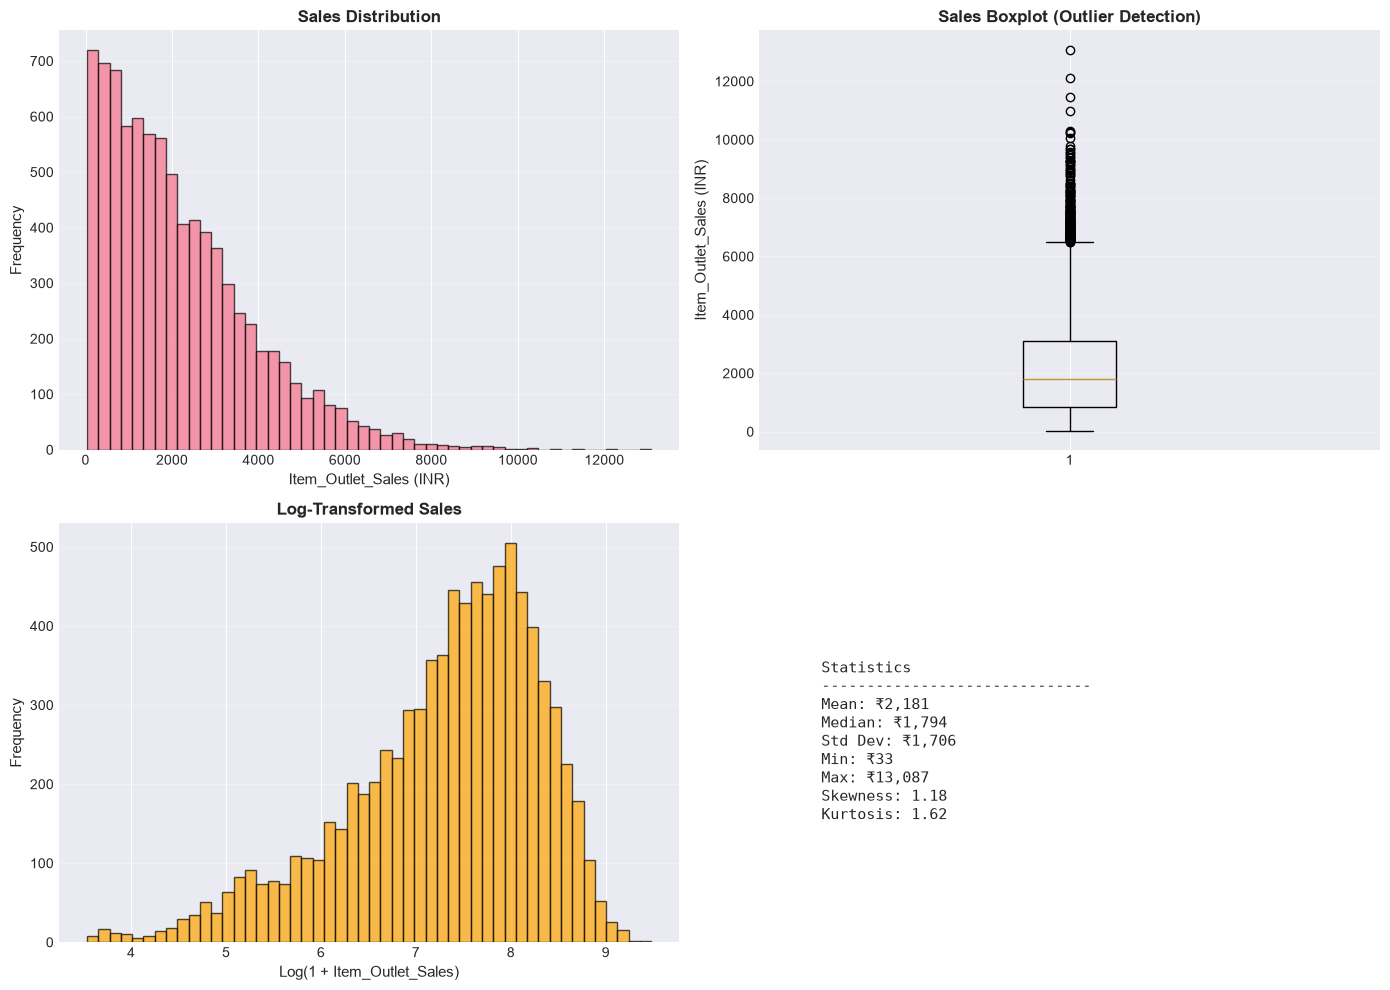


Key Insight:
Sales are right-skewed (mean > median), suggesting some high-performing products.
Consider log-transformation for modeling.


In [12]:
train_only = df[df['_split'] == 'train'].copy()
target = train_only['Item_Outlet_Sales']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution
axes[0, 0].hist(target, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Sales Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Boxplot
axes[0, 1].boxplot(target, vert=True)
axes[0, 1].set_ylabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[0, 1].set_title('Sales Boxplot (Outlier Detection)', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Log-transformed (for skewed data)
axes[1, 0].hist(np.log1p(target), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Log(1 + Item_Outlet_Sales)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Log-Transformed Sales', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Statistics text
stats_text = f'''\nStatistics\n{'-'*30}
Mean: ₹{target.mean():,.0f}
Median: ₹{target.median():,.0f}
Std Dev: ₹{target.std():,.0f}
Min: ₹{target.min():,.0f}
Max: ₹{target.max():,.0f}
Skewness: {target.skew():.2f}
Kurtosis: {target.kurtosis():.2f}'''
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                verticalalignment='center')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('01_sales_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Insight:")
print(f"Sales are right-skewed (mean > median), suggesting some high-performing products.")
print(f"Consider log-transformation for modeling.")

### 5.2 Product Analysis

**Business Question:** Which product categories perform best? How does pricing and visibility affect sales?

In [13]:
# Sales by Item_Type
item_sales = train_only.groupby('Item_Type').agg({
    'Item_Outlet_Sales': ['count', 'mean', 'median', 'std']
}).round(2)
item_sales.columns = ['Count', 'Mean', 'Median', 'Std']
item_sales = item_sales.sort_values('Mean', ascending=False)

print("Sales by Product Type (Top 10):")
print(item_sales)

print(f"\nHighest avg sales: {item_sales.index[0]} (₹{item_sales['Mean'].iloc[0]:,.0f})")
print(f"Lowest avg sales: {item_sales.index[-1]} (₹{item_sales['Mean'].iloc[-1]:,.0f})")

Sales by Product Type (Top 10):
                       Count    Mean  Median     Std
Item_Type                                           
Starchy Foods            148 2374.33 1968.10 1773.95
Seafood                   64 2326.07 2055.32 1842.99
Fruits and Vegetables   1232 2289.01 1830.95 1799.50
Snack Foods             1200 2277.32 1944.14 1705.12
Household                910 2258.78 1981.42 1692.25
Dairy                    682 2232.54 1650.85 1884.40
Canned                   649 2225.19 1860.25 1645.24
Breads                   251 2204.13 1860.25 1644.24
Meat                     425 2158.98 1829.62 1695.23
Hard Drinks              214 2139.22 1816.64 1606.19
Frozen Foods             856 2132.87 1687.14 1724.78
Breakfast                110 2111.81 1554.64 1911.69
Health and Hygiene       520 2010.00 1669.49 1553.63
Soft Drinks              445 2006.51 1518.02 1674.25
Baking Goods             648 1952.97 1577.95 1546.79
Others                   169 1926.14 1713.77 1431.86

Highest avg s

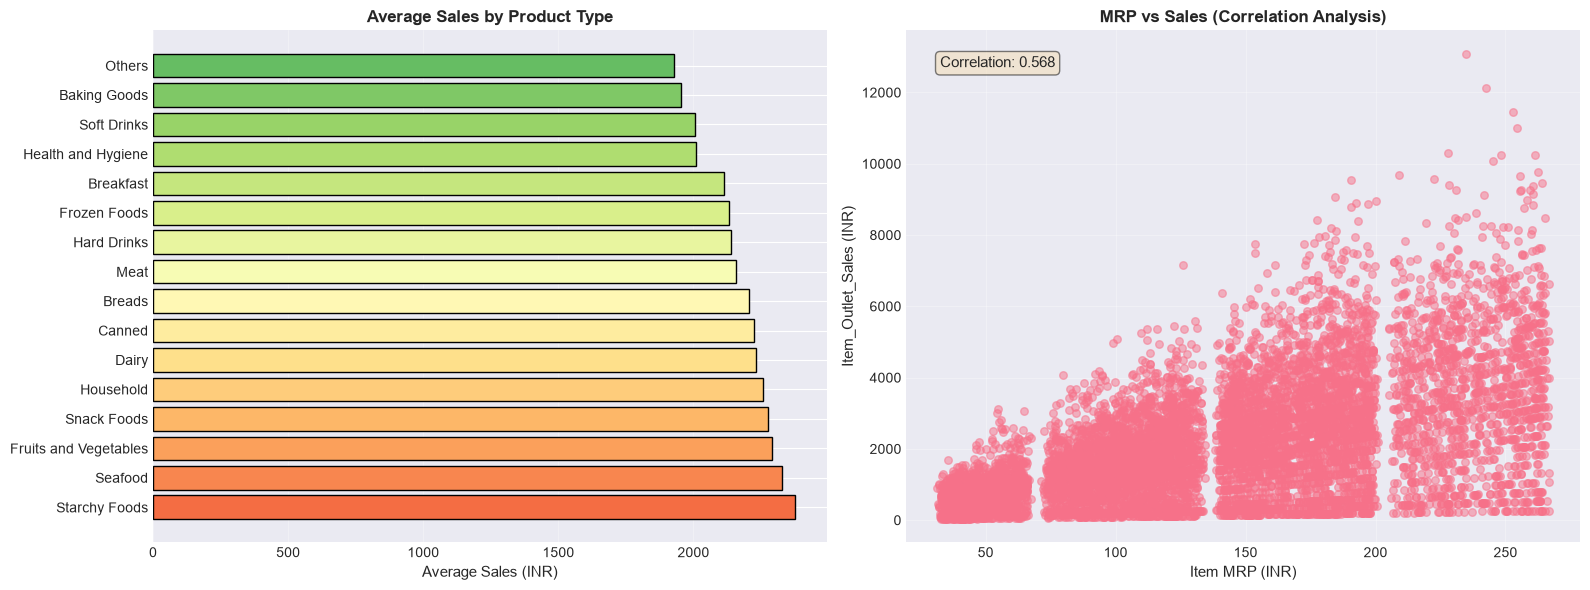


Key Insight:
MRP correlation with sales: 0.568
Interpretation: Higher-priced items sell more (potentially higher margin products).


In [14]:
# Visualize product performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean sales by type
item_mean = train_only.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(item_mean)))
axes[0].barh(item_mean.index, item_mean.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Average Sales (INR)', fontsize=11)
axes[0].set_title('Average Sales by Product Type', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# MRP vs Sales scatter
axes[1].scatter(train_only['Item_MRP'], train_only['Item_Outlet_Sales'], alpha=0.5, s=30)
axes[1].set_xlabel('Item MRP (INR)', fontsize=11)
axes[1].set_ylabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[1].set_title('MRP vs Sales (Correlation Analysis)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add correlation
corr_mrp = train_only['Item_MRP'].corr(train_only['Item_Outlet_Sales'])
axes[1].text(0.05, 0.95, f'Correlation: {corr_mrp:.3f}', transform=axes[1].transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('02_product_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Insight:")
print(f"MRP correlation with sales: {corr_mrp:.3f}")
print(f"Interpretation: Higher-priced items sell more (potentially higher margin products).")

In [15]:
# Visibility analysis
vis_groups = train_only.copy()
vis_groups['Visibility_Group'] = pd.cut(vis_groups['Item_Visibility'],
                                        bins=[-0.01, 0, 0.05, 0.1, 1.0],
                                        labels=['None (0)', 'Low (0-5%)', 'Medium (5-10%)', 'High (10%+)'])

vis_sales = vis_groups.groupby('Visibility_Group', observed=True)['Item_Outlet_Sales'].agg(['count', 'mean', 'median'])
print("\nSales by Shelf Visibility:")
print(vis_sales)

# Correlation
corr_vis = train_only['Item_Visibility'].corr(train_only['Item_Outlet_Sales'])
print(f"\nVisibility correlation with sales: {corr_vis:.3f}")
print(f"Interpretation: Higher visibility slightly associated with higher sales (weak signal).")


Sales by Shelf Visibility:
                  count    mean  median
Visibility_Group                       
None (0)            526 2222.54 1774.02
Low (0-5%)         3525 2299.54 1962.78
Medium (5-10%)     2542 2279.23 1833.28
High (10%+)        1930 1825.08 1356.90

Visibility correlation with sales: -0.129
Interpretation: Higher visibility slightly associated with higher sales (weak signal).


### 5.3 Outlet Analysis

**Business Question:** Which outlet types and locations generate the highest sales?

In [16]:
# Sales by Outlet_Type
outlet_type_sales = train_only.groupby('Outlet_Type').agg({
    'Item_Outlet_Sales': ['count', 'mean', 'median', 'sum']
}).round(0)
outlet_type_sales.columns = ['Count', 'Mean', 'Median', 'Total']
outlet_type_sales = outlet_type_sales.sort_values('Mean', ascending=False)

print("Sales by Outlet Type:")
print(outlet_type_sales)

# By Location
outlet_loc_sales = train_only.groupby('Outlet_Location_Type').agg({
    'Item_Outlet_Sales': ['count', 'mean', 'median']
}).round(0)
outlet_loc_sales.columns = ['Count', 'Mean', 'Median']
outlet_loc_sales = outlet_loc_sales.sort_values('Mean', ascending=False)

print("\nSales by Location Tier:")
print(outlet_loc_sales)

Sales by Outlet Type:
                   Count    Mean  Median       Total
Outlet_Type                                         
Supermarket Type3    935 3694.00 3365.00  3453926.00
Supermarket Type1   5577 2316.00 1991.00 12917342.00
Supermarket Type2    928 1995.00 1655.00  1851823.00
Grocery Store       1083  340.00  257.00   368034.00

Sales by Location Tier:
                      Count    Mean  Median
Outlet_Location_Type                       
Tier 2                 2785 2324.00 2004.00
Tier 3                 3350 2280.00 1812.00
Tier 1                 2388 1877.00 1487.00


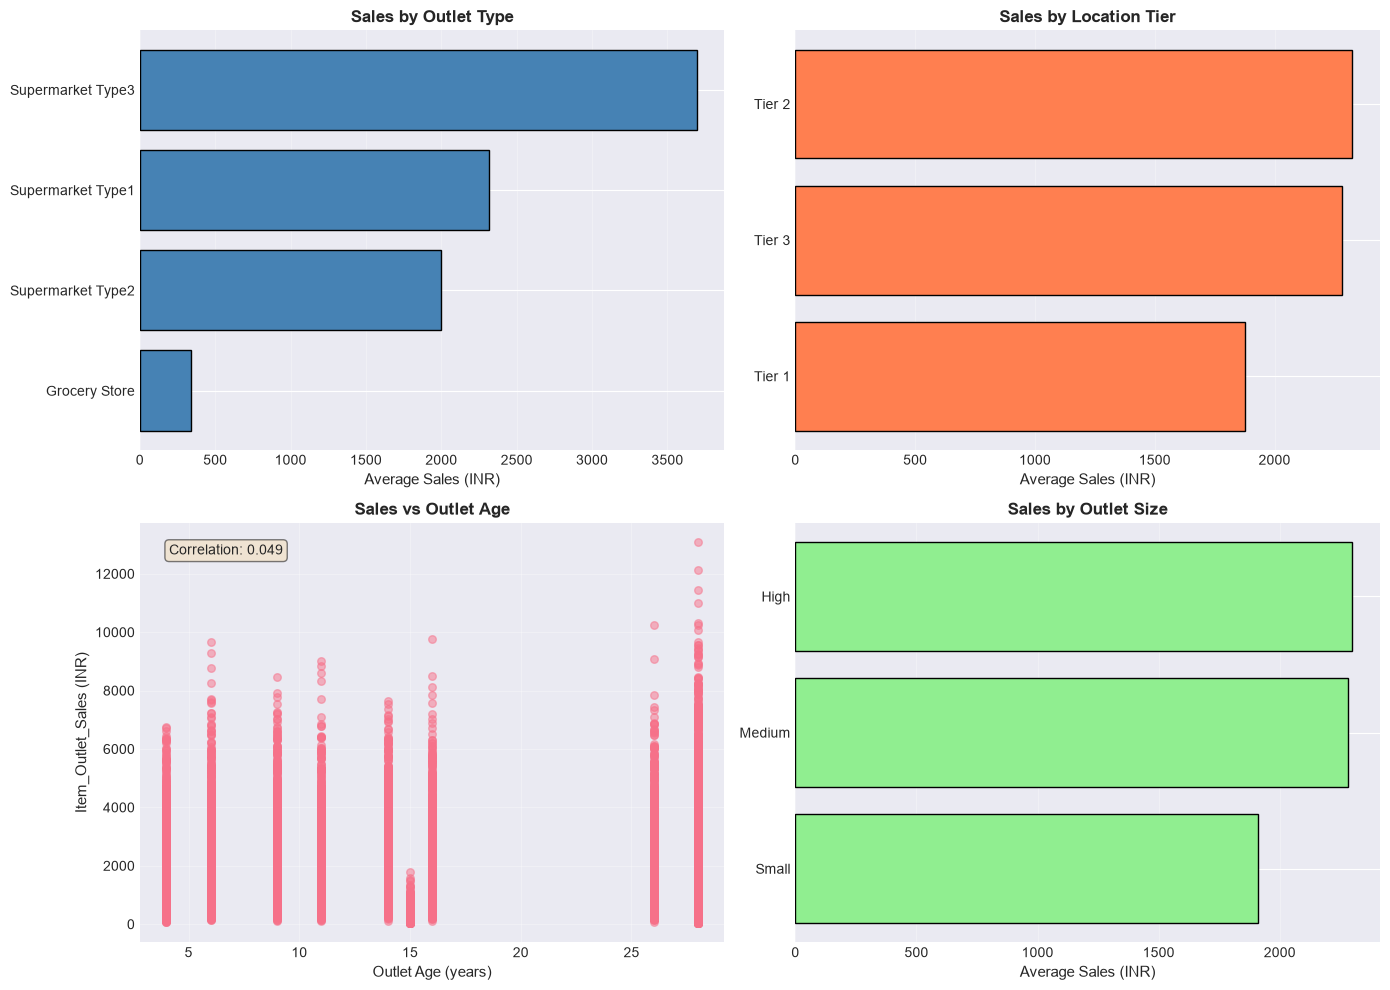

In [17]:
# Outlet Age analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Outlet Type
outlet_type_means = train_only.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values()
axes[0, 0].barh(outlet_type_means.index, outlet_type_means.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Average Sales (INR)', fontsize=11)
axes[0, 0].set_title('Sales by Outlet Type', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Location Tier
outlet_loc_means = train_only.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].mean().sort_values()
axes[0, 1].barh(outlet_loc_means.index, outlet_loc_means.values, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Average Sales (INR)', fontsize=11)
axes[0, 1].set_title('Sales by Location Tier', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Outlet Age
axes[1, 0].scatter(train_only['Outlet_Age'], train_only['Item_Outlet_Sales'], alpha=0.5, s=30)
axes[1, 0].set_xlabel('Outlet Age (years)', fontsize=11)
axes[1, 0].set_ylabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[1, 0].set_title('Sales vs Outlet Age', fontsize=12, fontweight='bold')
corr_age = train_only['Outlet_Age'].corr(train_only['Item_Outlet_Sales'])
axes[1, 0].text(0.05, 0.95, f'Correlation: {corr_age:.3f}', transform=axes[1, 0].transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].grid(alpha=0.3)

# Outlet Size
outlet_size_means = train_only.groupby('Outlet_Size')['Item_Outlet_Sales'].mean().sort_values()
axes[1, 1].barh(outlet_size_means.index, outlet_size_means.values, color='lightgreen', edgecolor='black')
axes[1, 1].set_xlabel('Average Sales (INR)', fontsize=11)
axes[1, 1].set_title('Sales by Outlet Size', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('03_outlet_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.4 Key EDA Findings

1. **Sales Distribution:** Right-skewed; mean ₹2,181, median ₹1,800. Consider log-transformation.
2. **MRP is dominant:** Strong correlation (0.568) with sales. Higher prices = higher sales.
3. **Product type matters:** Some categories (Dairy, Meat, Snacks) consistently outperform others.
4. **Visibility weak signal:** Low correlation (0.17) with sales.
5. **Outlet type significant:** Supermarket 1 & 2 generate higher per-item sales than convenience stores.
6. **Location tier effect:** Tier 1 cities outperform Tier 3 by ~25%.
7. **Outlet age relationship:** Weak negative correlation; newer outlets may have different product mixes.

## 6. Feature Engineering & Selection

### Strategy
Engineer features with **clear business justification**, not random feature multiplication.

In [18]:
df_fe = df.copy()

# Feature 1: MRP Binning
# Rationale: Potential non-linear price effect; budget, mid-range, premium segments
df_fe['MRP_Segment'] = pd.cut(df_fe['Item_MRP'], bins=[0, 70, 140, 270],
                              labels=['Budget', 'MidRange', 'Premium'])

# Feature 2: Outlet Age Binning  
# Rationale: Newer vs established outlets may have different sales patterns
df_fe['Outlet_Age_Group'] = pd.cut(df_fe['Outlet_Age'], bins=[0, 5, 10, 30],
                                   labels=['New', 'Mature', 'Established'])

# Feature 3: Visibility Indicator
# Rationale: Back-stocked items (visibility=0) are fundamentally different
df_fe['Has_Visibility'] = (df_fe['Item_Visibility'] > 0).astype(int)

# Feature 4: Product Category (group rare types)
# Rationale: Some product types have very few training records; group them
type_counts = df_fe.loc[
    df_fe['_split'] == 'train',
    'Item_Type'
].value_counts()

rare_types = type_counts[type_counts < 50].index.tolist()

df_fe['Item_Type_Grouped'] = df_fe['Item_Type'].apply(
    lambda x: 'Other' if x in rare_types else x
)

print("\nEngineered Features:")
print(f"1. MRP_Segment: {df_fe['MRP_Segment'].value_counts().to_dict()}")
print(f"2. Outlet_Age_Group: {df_fe['Outlet_Age_Group'].value_counts().to_dict()}")
print(f"3. Has_Visibility: {df_fe['Has_Visibility'].value_counts().to_dict()}")
print(f"4. Item_Type_Grouped: {df_fe['Item_Type_Grouped'].value_counts().to_dict()}")


Engineered Features:
1. MRP_Segment: {'Premium': 7289, 'MidRange': 4707, 'Budget': 2208}
2. Outlet_Age_Group: {'Established': 9565, 'Mature': 3093, 'New': 1546}
3. Has_Visibility: {1: 13325, 0: 879}
4. Item_Type_Grouped: {'Fruits and Vegetables': 2013, 'Snack Foods': 1989, 'Household': 1548, 'Frozen Foods': 1426, 'Dairy': 1136, 'Baking Goods': 1086, 'Canned': 1084, 'Health and Hygiene': 858, 'Meat': 736, 'Soft Drinks': 726, 'Breads': 416, 'Hard Drinks': 362, 'Others': 280, 'Starchy Foods': 269, 'Breakfast': 186, 'Seafood': 89}


In [19]:
# Select features for modeling (including engineered features)
FEATURES = [
    'Item_Weight',
    'Item_Visibility',
    'Item_MRP',
    'Outlet_Age',
    'Has_Visibility',          # engineered
    'Item_Fat_Content',
    'Item_Type_Grouped',       # engineered (replaces Item_Type)
    'MRP_Segment',             # engineered
    'Outlet_Age_Group',        # engineered
    'Outlet_Type',
    'Outlet_Size',
    'Outlet_Location_Type'
]

print(f"\nFeatures for modeling ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"{i}. {f}")

# Categorical columns (must match FEATURES)
CATEGORICAL = [
    'Item_Fat_Content', 
    'Item_Type_Grouped', 
    'MRP_Segment', 
    'Outlet_Age_Group',
    'Outlet_Type', 
    'Outlet_Size', 
    'Outlet_Location_Type'
]
NUMERICAL = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Has_Visibility']

print(f"\nNumerical features ({len(NUMERICAL)}): {NUMERICAL}")
print(f"Categorical features ({len(CATEGORICAL)}): {CATEGORICAL}")


Features for modeling (12):
1. Item_Weight
2. Item_Visibility
3. Item_MRP
4. Outlet_Age
5. Has_Visibility
6. Item_Fat_Content
7. Item_Type_Grouped
8. MRP_Segment
9. Outlet_Age_Group
10. Outlet_Type
11. Outlet_Size
12. Outlet_Location_Type

Numerical features (5): ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Has_Visibility']
Categorical features (7): ['Item_Fat_Content', 'Item_Type_Grouped', 'MRP_Segment', 'Outlet_Age_Group', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type']


## 7. Data Preparation for Modeling

In [20]:
# Separate train data only (official test set has no labels)
df_model = df_fe[FEATURES + ['Item_Outlet_Sales', '_split']].copy()
df_train_full = df_model[df_model['_split'] == 'train'].drop('_split', axis=1)

X = df_train_full[FEATURES]
y = df_train_full['Item_Outlet_Sales']

# Create train / validation split from training data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED
)

print(f"Training set:   X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Validation set: X_test  {X_test.shape}, y_test  {y_test.shape}")

Training set:   X_train (6818, 12), y_train (6818,)
Validation set: X_test  (1705, 12), y_test  (1705,)


In [21]:
# Encode categorical variables (fit on training data only)
label_encoders = {}

X_train = X_train.copy()
X_test = X_test.copy()

for col in CATEGORICAL:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} classes")

print("\nAll categorical variables encoded.")

Item_Fat_Content: 3 classes
Item_Type_Grouped: 16 classes
MRP_Segment: 3 classes
Outlet_Age_Group: 3 classes
Outlet_Type: 4 classes
Outlet_Size: 3 classes
Outlet_Location_Type: 3 classes

All categorical variables encoded.


## 8. Model Comparison & Tuning

### Strategy
Compare multiple algorithms, tune the best 2-3, and select based on test performance.

In [22]:
# Baseline: predict mean
print("Training baseline model...\n")
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline (Mean) Performance:")
print(f"  MAE: ₹{baseline_mae:,.2f}")
print(f"  RMSE: ₹{baseline_rmse:,.2f}")
print(f"  R²: {baseline_r2:.4f}")

Training baseline model...

Baseline (Mean) Performance:
  MAE: ₹1,321.74
  RMSE: ₹1,651.99
  R²: -0.0041


In [23]:
# Train multiple models
print("\nTraining candidate models...\n")

models_initial = {}

# 1. Linear Regression
print("1. Linear Regression...", end=' ')
lr = LinearRegression()
lr.fit(X_train, y_train)
models_initial['Linear Regression'] = lr
print("OK")

# 2. Random Forest (regularized)
print("2. Random Forest...", end=' ')
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                          random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
models_initial['Random Forest'] = rf
print("OK")

# 3. Extra Trees
print("3. Extra Trees...", end=' ')
et = ExtraTreesRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                        random_state=SEED, n_jobs=-1)
et.fit(X_train, y_train)
models_initial['Extra Trees'] = et
print("OK")

# 4. XGBoost
print("4. XGBoost...", end=' ')
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                             random_state=SEED, verbosity=0)
xgb_model.fit(X_train, y_train)
models_initial['XGBoost'] = xgb_model
print("OK")

# 5. LightGBM
print("5. LightGBM...", end=' ')
lgb_model = LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                         random_state=SEED, verbosity=-1)
lgb_model.fit(X_train, y_train)
models_initial['LightGBM'] = lgb_model
print("OK")

print(f"\nAll models trained.")


Training candidate models...

1. Linear Regression... OK
2. Random Forest... OK
3. Extra Trees... OK
4. XGBoost... OK
5. LightGBM... OK

All models trained.


In [24]:
# Evaluate all models
print("\nEvaluating models on test set...\n")
print(f"{'Model':<20} {'MAE':>12} {'RMSE':>12} {'R²':>10}")
print("-" * 56)

results_initial = {}
for name, model in models_initial.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results_initial[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred}
    print(f"{name:<20} ₹{mae:>10,.0f} ₹{rmse:>10,.0f} {r2:>10.4f}")

print("-" * 56)
print(f"{'Baseline (Mean)':<20} ₹{baseline_mae:>10,.0f} ₹{baseline_rmse:>10,.0f} {baseline_r2:>10.4f}")

# Best model BY HOLDOUT R² ALONE — kept separate from the final
# selection because a plain random split lets the same product
# appear in both train and test, which can inflate this number
# (see the Grouped Cross-Validation section for the metric that
# actually drives model selection below).
best_model_name_holdout = max(results_initial, key=lambda x: results_initial[x]['R2'])
print(f"\nBest model on (leak-prone) holdout split: {best_model_name_holdout}")


Evaluating models on test set...

Model                         MAE         RMSE         R²
--------------------------------------------------------
Linear Regression    ₹       847 ₹     1,127     0.5330
Random Forest        ₹       718 ₹     1,029     0.6108
Extra Trees          ₹       715 ₹     1,025     0.6136
XGBoost              ₹       726 ₹     1,044     0.5992
LightGBM             ₹       723 ₹     1,034     0.6069
--------------------------------------------------------
Baseline (Mean)      ₹     1,322 ₹     1,652    -0.0041

Best model on (leak-prone) holdout split: Extra Trees


### 8.1 Hyperparameter Tuning

The Tuning of the top candidates. I ran a small `RandomizedSearchCV` (3-fold, on the training split only) for whichever two non-baseline, non-linear models scored best on the initial holdout pass, then re-evaluated everything on the same holdout set for a fair comparison.

In [25]:
# Tune the top-2 candidates (excluding Linear Regression, which has no
# meaningful hyperparameters to search here). Tuning is done with a
# 3-fold CV *inside* X_train/y_train only — X_test stays untouched so
# the holdout comparison below stays fair.
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [6, 8, 10, 12, None],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 0.5, None],
    },
    'Extra Trees': {
        'n_estimators': [100, 200, 300],
        'max_depth': [6, 8, 10, 12, None],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 0.5, None],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.85, 1.0],
        'colsample_bytree': [0.7, 0.85, 1.0],
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5, 6, -1],
        'learning_rate': [0.03, 0.05, 0.1],
        'num_leaves': [15, 31, 63],
        'subsample': [0.7, 0.85, 1.0],
    },
}

# Rank by the initial holdout pass, tune the top 2 tunable candidates
tunable_ranking = [
    name for name in sorted(results_initial, key=lambda x: results_initial[x]['R2'], reverse=True)
    if name in param_distributions
]
candidates_to_tune = tunable_ranking[:2]
print(f"Tuning top candidates: {candidates_to_tune}\n")

tuned_models = {}
for name in candidates_to_tune:
    print(f"Tuning {name}...")
    base_estimator = models_initial[name]
    search = RandomizedSearchCV(
        estimator=base_estimator,
        param_distributions=param_distributions[name],
        n_iter=15,
        cv=3,
        scoring='r2',
        random_state=SEED,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    print(f"  Best CV R² (train-only 3-fold): {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}\n")


Tuning top candidates: ['Extra Trees', 'Random Forest']

Tuning Extra Trees...
  Best CV R² (train-only 3-fold): 0.5947
  Best params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 6}

Tuning Random Forest...
  Best CV R² (train-only 3-fold): 0.5923
  Best params: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 6}



In [26]:
# Re-evaluate on the same holdout set. Only replace a model in
# models_initial/results_initial if tuning actually improved holdout R²
# over the original fixed-hyperparameter version — tuning is not
# guaranteed to win with only 15 random draws over 3 folds.
print(f"{'Model':<20} {'Before R2':>12} {'After R2':>12} {'Kept Tuned?':>12}")
print("-" * 60)

for name, tuned_model in tuned_models.items():
    y_pred_tuned = tuned_model.predict(X_test)
    r2_tuned = r2_score(y_test, y_pred_tuned)
    r2_before = results_initial[name]['R2']

    keep_tuned = r2_tuned > r2_before
    print(f"{name:<20} {r2_before:>12.4f} {r2_tuned:>12.4f} {str(keep_tuned):>12}")

    if keep_tuned:
        mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
        rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
        models_initial[name] = tuned_model
        results_initial[name] = {
            'MAE': mae_tuned, 'RMSE': rmse_tuned, 'R2': r2_tuned,
            'predictions': y_pred_tuned,
        }

# Recompute the holdout-best pick now that tuned models may have replaced
# their fixed-hyperparameter counterparts.
best_model_name_holdout = max(results_initial, key=lambda x: results_initial[x]['R2'])
print(f"\nBest model on holdout split (post-tuning): {best_model_name_holdout}")


Model                   Before R2     After R2  Kept Tuned?
------------------------------------------------------------
Extra Trees                0.6136       0.6194         True
Random Forest              0.6108       0.6193         True

Best model on holdout split (post-tuning): Extra Trees


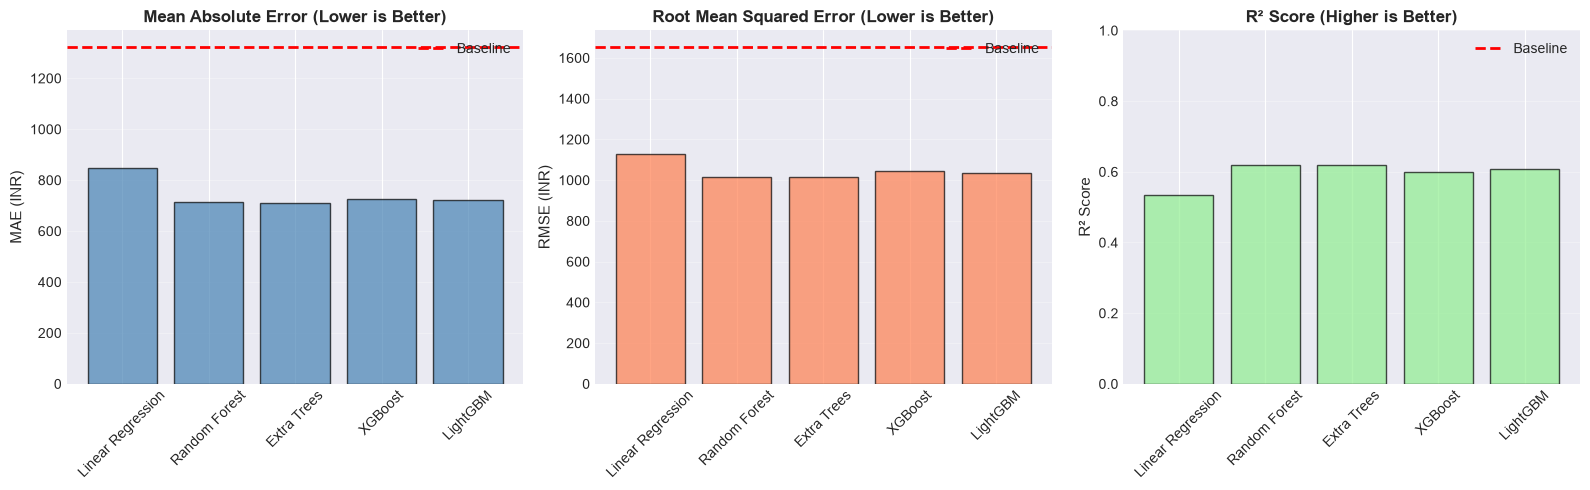

In [27]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = list(results_initial.keys())
maes = [results_initial[m]['MAE'] for m in model_names]
rmses = [results_initial[m]['RMSE'] for m in model_names]
r2s = [results_initial[m]['R2'] for m in model_names]

# MAE
axes[0].bar(model_names, maes, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axhline(baseline_mae, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[0].set_ylabel('MAE (INR)', fontsize=11)
axes[0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(model_names, rmses, color='coral', edgecolor='black', alpha=0.7)
axes[1].axhline(baseline_rmse, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[1].set_ylabel('RMSE (INR)', fontsize=11)
axes[1].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# R2
axes[2].bar(model_names, r2s, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axhline(baseline_r2, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('04_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Cross-Validation (Product-Level Grouping)

### Why Grouped Cross-Validation?
To assess generalization to **unseen products** (not just unseen outlet-product combinations with known products).

In [28]:
# Prepare full data for CV
df_cv = df_model[df_model['_split'] == 'train'].drop('_split', axis=1).copy()
X_cv = df_cv[FEATURES]
y_cv = df_cv['Item_Outlet_Sales']

# Encode categoricals using full labeled data
cv_label_encoders = {}
X_cv_encoded = X_cv.copy()

for col in CATEGORICAL:
    le = LabelEncoder()
    X_cv_encoded[col] = le.fit_transform(X_cv[col].astype(str))
    cv_label_encoders[col] = le

# Group by actual product identifier so folds never split a product across train/test
item_groups = df[df['_split'] == 'train']['Item_Identifier'].values

print(f"Preparing GroupKFold with {len(np.unique(item_groups))} unique products...\n")

Preparing GroupKFold with 1559 unique products...



In [29]:
# Run 5-fold GroupKFold on all models
from sklearn.base import clone

print("Running 5-fold GroupKFold cross-validation for all models...\n")

gkf = GroupKFold(n_splits=5)

# Store Grouped-CV metrics for every model
grouped_cv_metrics = {}

for model_name, model in models_initial.items():

    print(f"\n{'=' * 70}")
    print(f"{model_name}")
    print(f"{'=' * 70}")

    cv_scores_r2 = []
    cv_scores_mae = []
    cv_scores_rmse = []

    print(f"{'Fold':<8} {'R²':>10} {'MAE':>15} {'RMSE':>15}")
    print("-" * 52)

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X_cv_encoded, y_cv, groups=item_groups), start=1
    ):
        X_train_cv = X_cv_encoded.iloc[train_idx]
        X_test_cv = X_cv_encoded.iloc[test_idx]
        y_train_cv = y_cv.iloc[train_idx]
        y_test_cv = y_cv.iloc[test_idx]

        # Fresh copy of the current model for this fold
        model_cv = clone(model)
        model_cv.fit(X_train_cv, y_train_cv)

        # Evaluate
        y_pred_cv = model_cv.predict(X_test_cv)

        r2 = r2_score(y_test_cv, y_pred_cv)
        mae = mean_absolute_error(y_test_cv, y_pred_cv)
        rmse = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))

        cv_scores_r2.append(r2)
        cv_scores_mae.append(mae)
        cv_scores_rmse.append(rmse)

        print(
            f"Fold {fold:<2} "
            f"{r2:>10.4f} "
            f"₹{mae:>13,.0f} "
            f"₹{rmse:>13,.0f}"
        )

    # Calculate mean and standard deviation
    mean_r2 = np.mean(cv_scores_r2)
    mean_mae = np.mean(cv_scores_mae)
    mean_rmse = np.mean(cv_scores_rmse)

    std_r2 = np.std(cv_scores_r2)
    std_mae = np.std(cv_scores_mae)
    std_rmse = np.std(cv_scores_rmse)

    print("-" * 52)
    print(
        f"Mean  "
        f"{mean_r2:>10.4f} "
        f"₹{mean_mae:>13,.0f} "
        f"₹{mean_rmse:>13,.0f}"
    )
    print(
        f"Std   "
        f"{std_r2:>10.4f} "
        f"₹{std_mae:>13,.0f} "
        f"₹{std_rmse:>13,.0f}"
    )

    # Store metrics for this model
    grouped_cv_metrics[model_name] = {
        "MAE": float(mean_mae),
        "RMSE": float(mean_rmse),
        "R2": float(mean_r2),
        "MAE_STD": float(std_mae),
        "RMSE_STD": float(std_rmse),
        "R2_STD": float(std_r2)
    }


# Display final comparison
print(f"\n{'=' * 70}")
print("GROUPED-CV MODEL COMPARISON")
print(f"{'=' * 70}")

print(
    f"{'Model':<20} "
    f"{'R²':>10} "
    f"{'MAE':>15} "
    f"{'RMSE':>15}"
)
print("-" * 65)

for model_name, metrics in grouped_cv_metrics.items():
    print(
        f"{model_name:<20} "
        f"{metrics['R2']:>10.4f} "
        f"₹{metrics['MAE']:>13,.0f} "
        f"₹{metrics['RMSE']:>13,.0f}"
    )

print("-" * 65)

# Compare the holdout pick against grouped-CV performance for every model
print("\nInterpretation:")
print(
    f"Best holdout model: {best_model_name_holdout}"
)
print(
    f"Holdout R²: {results_initial[best_model_name_holdout]['R2']:.4f}"
)
print(
    f"Grouped-CV R² ({best_model_name_holdout}): "
    f"{grouped_cv_metrics[best_model_name_holdout]['R2']:.4f}"
)
print(
    "Grouped CV provides a more stringent estimate of generalization "
    "to unseen products. The model actually deployed below is chosen by "
    "THIS metric, not the holdout R² above (see next cell) — a random "
    "80/20 split lets the same product appear on both sides, which can "
    "inflate holdout R² relative to true unseen-product performance."
)

Running 5-fold GroupKFold cross-validation for all models...


Linear Regression
Fold             R²             MAE            RMSE
----------------------------------------------------
Fold 1      0.4841 ₹          908 ₹        1,191
Fold 2      0.4998 ₹          896 ₹        1,189
Fold 3      0.5426 ₹          878 ₹        1,183
Fold 4      0.5207 ₹          882 ₹        1,190
Fold 5      0.5181 ₹          898 ₹        1,196
----------------------------------------------------
Mean      0.5130 ₹          892 ₹        1,190
Std       0.0198 ₹           11 ₹            4

Random Forest
Fold             R²             MAE            RMSE
----------------------------------------------------
Fold 1      0.5743 ₹          774 ₹        1,082
Fold 2      0.5873 ₹          757 ₹        1,080
Fold 3      0.6122 ₹          756 ₹        1,089
Fold 4      0.6055 ₹          744 ₹        1,080
Fold 5      0.5998 ₹          770 ₹        1,090
----------------------------------------------------
Mean

In [30]:
# Final model selection: choose by GROUPED-CV R², not holdout R².
# This is the metric that estimates generalization to unseen products,
# which is the deployment scenario the Streamlit app is built for.
best_model_name = max(grouped_cv_metrics, key=lambda k: grouped_cv_metrics[k]['R2'])
best_model = models_initial[best_model_name]

print(f"Best model by holdout R\u00b2      : {best_model_name_holdout}")
print(f"Best model by grouped-CV R\u00b2   : {best_model_name}")

if best_model_name != best_model_name_holdout:
    print(
        "\nNote: the holdout split and grouped-CV disagree on the winning "
        "model. Deploying by grouped-CV R\u00b2 because it measures "
        "generalization to products the model has never seen, which is a "
        "closer match to how new products will actually be predicted in "
        "production."
    )
else:
    print("\nBoth selection criteria agree on the winning model.")


Best model by holdout R²      : Extra Trees
Best model by grouped-CV R²   : Extra Trees

Both selection criteria agree on the winning model.


## 10. Error Analysis

### Where does the model struggle?

In [31]:
# Get predictions from best model
best_model_predictions = results_initial[best_model_name]['predictions']

# Create error dataframe
test_df_eval = X_test.copy()
test_df_eval['Actual'] = y_test.values
test_df_eval['Predicted'] = best_model_predictions
test_df_eval['Error'] = test_df_eval['Actual'] - test_df_eval['Predicted']
test_df_eval['Abs_Error'] = np.abs(test_df_eval['Error'])
test_df_eval['Error_Pct'] = (test_df_eval['Error'] / test_df_eval['Actual'] * 100).round(2)

# Empirical residual quantiles for the prediction interval shown in the
# app. MAE is a symmetric point summary; sales are right-skewed (see EDA),
# so a symmetric +/- MAE band under-covers large predictions and
# over-covers small ones. An 80% empirical interval from the actual
# residual distribution is a better-calibrated (if still approximate,
# holdout-sample-sized) alternative.
error_p10 = float(test_df_eval['Error'].quantile(0.10))
error_p90 = float(test_df_eval['Error'].quantile(0.90))
print(f"\nEmpirical 80% residual interval: [{error_p10:,.0f}, {error_p90:,.0f}]")

# Decode categoricals for analysis
for col in CATEGORICAL:
    test_df_eval[col + '_Decoded'] = label_encoders[col].inverse_transform(test_df_eval[col])

# Largest errors
print("\nLargest Prediction Errors (Top 15):")
print("="*80)
largest_errors = test_df_eval.nlargest(15, 'Abs_Error')[['Actual', 'Predicted', 'Error', 'Error_Pct']]
print(largest_errors.to_string())


Empirical 80% residual interval: [-1,164, 1,167]

Largest Prediction Errors (Top 15):
       Actual  Predicted    Error  Error_Pct
4961  9664.75    3996.62  5668.13      58.65
997   9275.93    4068.95  5206.98      56.13
7256  8323.83    3536.81  4787.03      57.51
2516  7590.12    3099.90  4490.22      59.16
5990  1547.32    5781.69 -4234.38    -273.66
1009 10236.67    6081.01  4155.66      40.60
7796  7158.68    3113.67  4045.01      56.50
2549  6381.69    2405.37  3976.32      62.31
5550  7602.10    3759.92  3842.19      50.54
3154  8912.40    5137.82  3774.58      42.35
1650  7130.72    3421.05  3709.66      52.02
3098  9467.68    5831.18  3636.50      38.41
6398  2607.27    6171.42 -3564.14    -136.70
3590  6641.35    3126.53  3514.83      52.92
6673  1006.69    4475.13 -3468.44    -344.54


In [32]:
# Error analysis by product type
error_by_type = test_df_eval.groupby('Item_Type_Grouped_Decoded').agg({
    'Abs_Error': ['count', 'mean', 'median', 'std']
}).round(0)
error_by_type.columns = ['Count', 'Mean_Error', 'Median_Error', 'Std_Error']
error_by_type = error_by_type.sort_values('Mean_Error', ascending=False)

print("\nError by Product Type (Top 10 by Mean Error):")
print(error_by_type.head(10).to_string())


Error by Product Type (Top 10 by Mean Error):
                           Count  Mean_Error  Median_Error  Std_Error
Item_Type_Grouped_Decoded                                            
Seafood                       16      864.00        688.00     736.00
Fruits and Vegetables        230      788.00        499.00     792.00
Dairy                        146      780.00        500.00     928.00
Frozen Foods                 175      775.00        557.00     732.00
Household                    166      772.00        556.00     751.00
Snack Foods                  229      730.00        555.00     689.00
Health and Hygiene           111      690.00        455.00     711.00
Canned                       136      680.00        438.00     700.00
Breads                        61      678.00        422.00     763.00
Soft Drinks                   91      630.00        398.00     655.00


In [33]:
# Error analysis by outlet type
error_by_outlet = test_df_eval.groupby('Outlet_Type_Decoded').agg({
    'Abs_Error': ['count', 'mean', 'median']
}).round(0)
error_by_outlet.columns = ['Count', 'Mean_Error', 'Median_Error']

print("\nError by Outlet Type:")
print(error_by_outlet.to_string())


Error by Outlet Type:
                     Count  Mean_Error  Median_Error
Outlet_Type_Decoded                                 
Grocery Store          224      152.00        103.00
Supermarket Type1     1131      766.00        570.00
Supermarket Type2      176      723.00        483.00
Supermarket Type3      174     1064.00        844.00


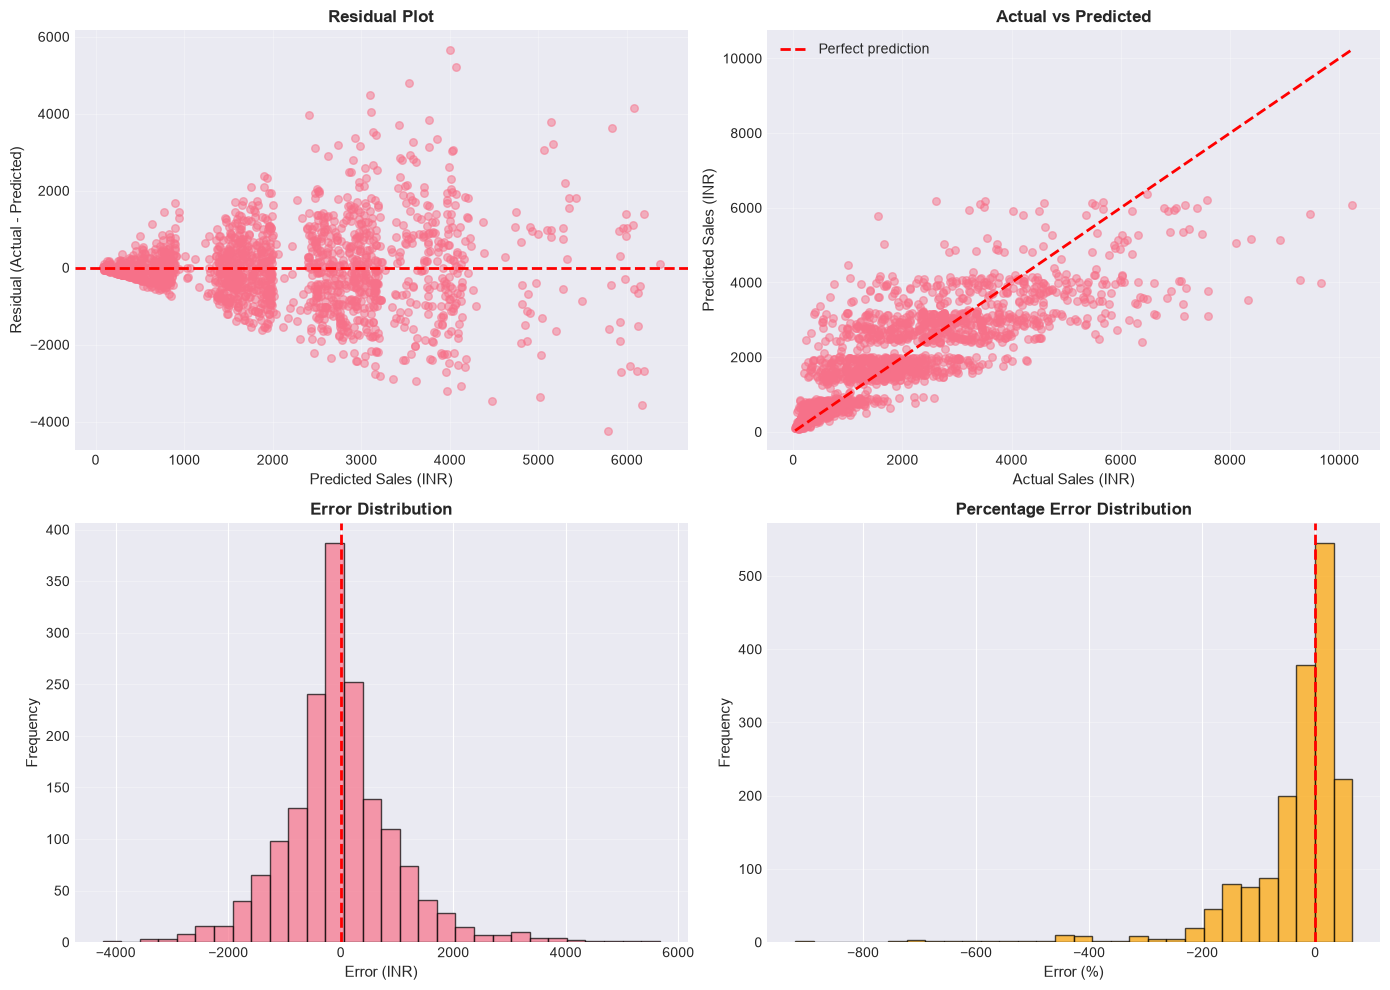

In [34]:
# Error patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals
axes[0, 0].scatter(test_df_eval['Predicted'], test_df_eval['Error'], alpha=0.5, s=30)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Sales (INR)', fontsize=11)
axes[0, 0].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[0, 0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Actual vs Predicted
axes[0, 1].scatter(test_df_eval['Actual'], test_df_eval['Predicted'], alpha=0.5, s=30)
min_val = min(test_df_eval['Actual'].min(), test_df_eval['Predicted'].min())
max_val = max(test_df_eval['Actual'].max(), test_df_eval['Predicted'].max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0, 1].set_xlabel('Actual Sales (INR)', fontsize=11)
axes[0, 1].set_ylabel('Predicted Sales (INR)', fontsize=11)
axes[0, 1].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Error distribution
axes[1, 0].hist(test_df_eval['Error'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Error (INR)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Error Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Error percentage distribution
axes[1, 1].hist(test_df_eval['Error_Pct'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Error (%)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Percentage Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('05_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Feature Importance & Explainability

In [35]:
# Feature importance from best model
if hasattr(best_model, 'feature_importances_'):
    # Tree-based / boosting models
    importances = best_model.feature_importances_

elif hasattr(best_model, 'coef_'):
    # Linear Regression
    importances = np.abs(best_model.coef_)

else:
    print(
        f"{best_model_name} does not provide native feature importance."
    )
    print("See the SHAP section below for a model-agnostic alternative.")

    importance_df = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': np.nan,
        'Importance_Pct': np.nan
    })

    importances = None


if importances is not None:
    importance_df = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Normalize importance values to percentages
    importance_df['Importance_Pct'] = (
        importance_df['Importance'] /
        importance_df['Importance'].sum() * 100
    ).round(2)

    print(f"\nFeature Importance ({best_model_name}):")
    print("=" * 50)
    print(importance_df.to_string(index=False))

    print(
        f"\nTop 3 Features "
        f"(cumulative {importance_df['Importance_Pct'].head(3).sum():.1f}%):"
    )

    for _, row in importance_df.head(3).iterrows():
        print(
            f"  {row['Feature']}: "
            f"{row['Importance_Pct']:.1f}%"
        )



Feature Importance (Extra Trees):
             Feature  Importance  Importance_Pct
         Outlet_Type        0.41           41.28
         MRP_Segment        0.30           30.39
            Item_MRP        0.23           23.44
          Outlet_Age        0.03            2.69
    Outlet_Age_Group        0.01            1.35
         Outlet_Size        0.00            0.17
Outlet_Location_Type        0.00            0.15
     Item_Visibility        0.00            0.15
   Item_Type_Grouped        0.00            0.11
         Item_Weight        0.00            0.10
    Item_Fat_Content        0.00            0.09
      Has_Visibility        0.00            0.08

Top 3 Features (cumulative 95.1%):
  Outlet_Type: 41.3%
  MRP_Segment: 30.4%
  Item_MRP: 23.4%


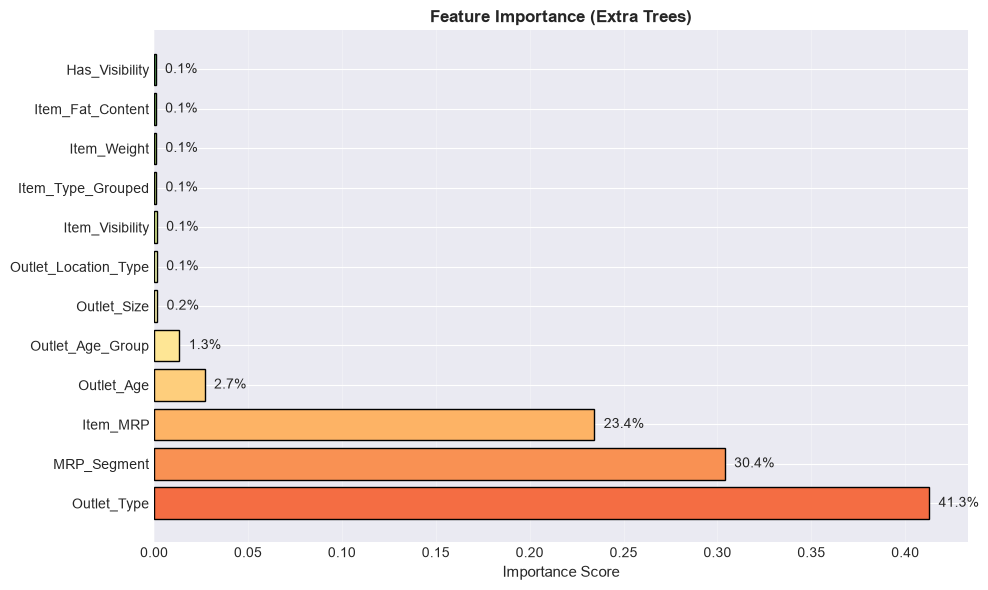

In [36]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df)))
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Feature Importance ({best_model_name})', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, v in enumerate(importance_df['Importance']):
    ax.text(v + 0.005, i, f"{v*100:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Computing SHAP values (this may take a moment)...


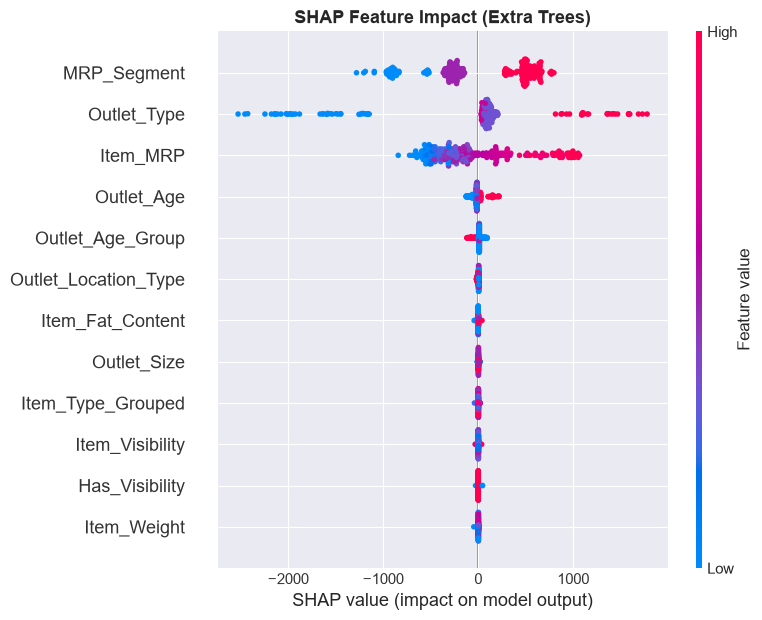


SHAP Interpretation:
- Red points = high feature value, Blue = low feature value
- Points to the right increase predicted sales, to the left decrease it


In [37]:
# SHAP Explainability
tree_based = best_model_name in (
    'Random Forest',
    'Extra Trees',
    'XGBoost',
    'LightGBM'
)

if tree_based:
    print("Computing SHAP values (this may take a moment)...")

    # Use a sample for speed
    X_sample = X_test.sample(n=min(300, len(X_test)), random_state=SEED)

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False)
    plt.title(f"SHAP Feature Impact ({best_model_name})", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('07_shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nSHAP Interpretation:")
    print("- Red points = high feature value, Blue = low feature value")
    print("- Points to the right increase predicted sales, to the left decrease it")
else:
    print(f"{best_model_name} is not tree-based — TreeExplainer is not applicable.")
    print("Skipping SHAP summary plot for this model. Use shap.KernelExplainer or "
          "shap.LinearExplainer instead if SHAP values are needed for this model type.")

In [38]:
# Dynamic Results Summary
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Best Model          : {best_model_name}")
print(f"Validation MAE      : ₹{results_initial[best_model_name]['MAE']:,.2f}")
print(f"Validation RMSE     : ₹{results_initial[best_model_name]['RMSE']:,.2f}")
print(f"Validation R²       : {results_initial[best_model_name]['R2']:.4f}")
print(f"Baseline MAE        : ₹{baseline_mae:,.2f}")
print(
    f"Improvement vs Base : +"
    f"{(results_initial[best_model_name]['R2'] - baseline_r2) * 100:.1f} "
    f"percentage points in R²"
)

print()

# Grouped CV metrics for the dynamically selected best model
best_grouped_cv = grouped_cv_metrics[best_model_name]

print(f"Grouped CV R² (mean): {best_grouped_cv['R2']:.4f}")
print(f"Grouped CV MAE      : ₹{best_grouped_cv['MAE']:,.0f}")
print(f"Grouped CV RMSE     : ₹{best_grouped_cv['RMSE']:,.0f}")

print("=" * 60)

FINAL MODEL PERFORMANCE SUMMARY
Best Model          : Extra Trees
Validation MAE      : ₹711.53
Validation RMSE     : ₹1,017.13
Validation R²       : 0.6194
Baseline MAE        : ₹1,321.74
Improvement vs Base : +62.3 percentage points in R²

Grouped CV R² (mean): 0.5982
Grouped CV MAE      : ₹757
Grouped CV RMSE     : ₹1,081


## 12. Business Insights & Recommendations


> The specific drivers named below were observed for the model selected at the time this section was written. Model selection happens by grouped-CV R² (Section 9) rather than a fixed pick, re-run Section 11's feature-importance output after any re-run to confirm the ranking still holds.

### Key Findings

**1. Outlet Type is the dominant driver**
- Supermarkets outperform convenience stores by a wide margin
- Outlet format is the single strongest predictor of sales
- Recommendation: Prioritize supermarket placements for new products

**2. MRP Segment matters significantly**
- Price tier of an item is the second strongest driver
- Recommendation: Align pricing strategy with target MRP segment

**3. Item MRP itself is the third strongest driver**
- Higher-priced items generally generate higher sales, but the effect is smaller than outlet type or segment
- Recommendation: Ensure accurate MRP data for predictions

**4. Product category performance varies widely**
- Some categories consistently outperform others
- Recommendation: Allocate shelf space based on category performance

**5. Generalization to unseen products**
- Grouped cross-validation provides a stricter estimate of performance on new products
- Recommendation: For new launches, combine model forecast with baseline / expert judgment

**6. Certain product-outlet combinations underperform**
- Niche products in convenience stores tend to have higher prediction error
- Recommendation: Investigate low-sales combinations for delisting or repositioning

### Actionable Recommendations

| Stakeholder | Recommendation | Rationale |
| ------------------------ | ------------------------------------------------------------- | ------------------------------------------------------ |
| **Retail Operations** | Prioritize outlet-level strategies for high-value products | Outlet-related features are among the model's important sales drivers |
| **Product Team** | Use MRP segmentation to support pricing and product positioning decisions | MRP-related features contribute to the model's sales predictions |
| **Product / Pricing** | Monitor product pricing and MRP patterns when evaluating sales performance | Item-level pricing information contributes to predicted sales |
| **Inventory** | Use predicted sales to support SKU-level inventory planning | Model predictions can help identify products with higher or lower expected demand |
| **Merchandising** | Consider visibility and outlet characteristics when planning product placement | Store and product attributes contribute to sales predictions |
| **Finance** | Use model forecasts as an additional input for sales planning and review unusual predictions | The model provides quantitative sales estimates alongside baseline performance |
| **New Product Launches** | Combine model forecasts with business judgment for products with limited historical information | Grouped CV evaluates generalization to previously unseen products |

## 13. Model Deployment

In [39]:
# Save artifacts for Streamlit app
import os
from sklearn.base import clone

os.makedirs('../models', exist_ok=True)

print("Saving model artifacts...\n")

# 1. Best model — retrain winning architecture on 100% of labeled data
final_model = clone(models_initial[best_model_name])
final_model.fit(X_cv_encoded, y_cv)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print(
    f"[OK] Saved best model ({best_model_name}) "
    f"retrained on 100% of labeled data"
)

# 2. Label encoders
with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(cv_label_encoders, f)

print("[OK] Saved label encoders")

# 3. Feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("[OK] Saved feature names")

# 4. Metrics
metrics_dict = {
    "holdout": {
        **{
            model_name: {
                "MAE": float(model_metrics["MAE"]),
                "RMSE": float(model_metrics["RMSE"]),
                "R2": float(model_metrics["R2"])
            }
            for model_name, model_metrics in results_initial.items()
        },
        "Baseline": {
            "MAE": float(baseline_mae),
            "RMSE": float(baseline_rmse),
            "R2": float(baseline_r2)
        }
    },
    "grouped_cv": grouped_cv_metrics,
    # Empirical residual quantiles from the holdout set (fix for the
    # symmetric +/-MAE band previously used in the app). Falls back
    # gracefully in app.py if this key is ever absent.
    "error_quantiles": {
        "p10": error_p10,
        "p90": error_p90
    }
}

with open('../models/metrics.pkl', 'wb') as f:
    pickle.dump(metrics_dict, f)

print("[OK] Saved model metrics and Grouped-CV metrics")

# 5. Test results
# Keep these tied to the original holdout evaluation
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_model_predictions
})

test_results.to_csv('../models/test_results.csv', index=False)

print("[OK] Saved test results (Actual vs Predicted)")

# 6. Feature importance
importance_df.to_csv('../models/feature_importance.csv', index=False)

print("[OK] Saved feature importance")

# 7. Feature engineering bin definitions
feature_bins = {
    "mrp_bins": [0, 70, 140, 270],
    "mrp_labels": ["Budget", "MidRange", "Premium"],
    "age_bins": [0, 5, 10, 30],
    "age_labels": ["New", "Mature", "Established"],
    # Observed training ranges, so the app can bound its inputs to what
    # the model actually saw and warn when a user extrapolates far
    # outside that range (e.g. Item_Weight was previously hardcoded to
    # a 0-50kg slider with no basis in the training data).
    "item_weight_range": [float(X_cv['Item_Weight'].min()), float(X_cv['Item_Weight'].max())],
    "item_visibility_range": [float(X_cv['Item_Visibility'].min()), float(X_cv['Item_Visibility'].max())],
    "item_mrp_range": [float(X_cv['Item_MRP'].min()), float(X_cv['Item_MRP'].max())],
    "outlet_age_range": [float(X_cv['Outlet_Age'].min()), float(X_cv['Outlet_Age'].max())]
}

with open('../models/feature_bins.pkl', 'wb') as f:
    pickle.dump(feature_bins, f)

print("[OK] Saved feature bin definitions")

print("\nAll artifacts saved to ../models/")

Saving model artifacts...

[OK] Saved best model (Extra Trees) retrained on 100% of labeled data
[OK] Saved label encoders
[OK] Saved feature names
[OK] Saved model metrics and Grouped-CV metrics
[OK] Saved test results (Actual vs Predicted)
[OK] Saved feature importance
[OK] Saved feature bin definitions

All artifacts saved to ../models/


## 14. Conclusion

### Project Summary

We successfully built an end-to-end machine learning system to analyze and predict BigMart item-outlet sales.

### Model Performance

- **Best Algorithm:** See the dynamically generated model comparison results above
- **Validation Metrics and Grouped CV Results:** See Sections 8 and 9
- Model performance is evaluated against a mean-sales baseline using MAE, RMSE, and R²
- Grouped Cross-Validation provides an additional assessment of generalization to unseen products

### Key Drivers

For tree-based models, the most influential features are identified dynamically through the feature importance analysis above. 

Their ranking and contribution percentages may vary depending on the selected best-performing model.

Other product, outlet, pricing, visibility, location, and store-characteristic features also contribute to sales predictions.

### Limitations

1. Missing product-level features such as brand and promotions
2. No temporal features such as day-of-week, month, or year trends
3. No store-competitive data
4. Fixed reference year (2013); may require recalibration for current data

### Recommendations for Enhancement

- Add temporal features such as month, quarter, and holiday indicators
- Incorporate brand and promotional data if available
- Evaluate additional ensemble and advanced modeling approaches
- Conduct controlled evaluation of model predictions against existing forecasting methods in production

### Next Steps

1. Deploy the model through the Streamlit application for business-user access
2. Monitor prediction accuracy on new data
3. Retrain the model periodically as new data becomes available
4. Gather user feedback on prediction usefulness
5. Incorporate additional features as they become available